In [1]:
1+1

2

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open("./data/names.txt").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
import random

BLOCK_SIZE = 3

def build_dataset(words):
    X, y =[], []
    for w in words:
        context = [0] * BLOCK_SIZE

        for c in w+'.':
            ix = stoi[c]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
        
    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X,y


random.seed(43)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1])
Xde, yde = build_dataset(words[n1:n2])
Xte, yte = build_dataset(words[n2:])

torch.Size([182460, 3]) torch.Size([182460])
torch.Size([22811, 3]) torch.Size([22811])
torch.Size([22875, 3]) torch.Size([22875])


In [42]:
n_embd = 10 #the dimensionality of char embedding vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * BLOCK_SIZE, n_hidden), generator=g)
b1 = torch.randn((n_hidden), generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn((vocab_size), generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [17]:
# same as before

lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())


      0/ 200000 : 23.6622
  10000/ 200000 : 2.3529
  20000/ 200000 : 1.8886
  30000/ 200000 : 2.4606
  40000/ 200000 : 2.5643
  50000/ 200000 : 2.1975
  60000/ 200000 : 2.0463
  70000/ 200000 : 2.2414
  80000/ 200000 : 2.1901
  90000/ 200000 : 2.6677
 100000/ 200000 : 1.9988
 110000/ 200000 : 1.9125
 120000/ 200000 : 2.0785
 130000/ 200000 : 2.2989
 140000/ 200000 : 2.1996
 150000/ 200000 : 1.8240
 160000/ 200000 : 1.5820
 170000/ 200000 : 2.2788
 180000/ 200000 : 1.7397
 190000/ 200000 : 2.0862


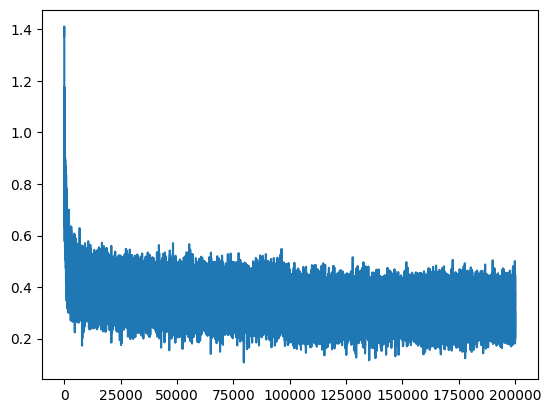

In [18]:
plt.plot(lossi)

In [22]:
@torch.no_grad() # you can also use something called a context manager with this, look it up
def split_loss(split):
    x,y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test' : (Xte, yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1167960166931152
val 2.206547260284424


In [37]:
# sampling

g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * BLOCK_SIZE
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)


        if ix==0:
            break
    
    print(''.join(itos[i] for i in out))

carmah.
amoriq.
khi.
milia.
aty.
salayane.
mahney.
den.
art.
kaqui.
ner.
kingcheiiv.
kaleigh.
ham.
joce.
quintis.
lilah.
jadai.
wajelo.
dearisi.


This is the starting point for today

Now to scrutinize, the initiialization of our weights and biases, there are a lot of things going wrong...

1 of the things is, when i notice the starting loss, is 23 point something, this is terrible starting loss...because, even if the NN chooses a char randomly, within 27 chars, the probability of choosing somehting should be 1/27 and not 23

In [41]:
expected_starting_loss = -torch.tensor(1/27.0).log()
expected_starting_loss

tensor(3.2958)

It shouldve been 3.29 and not 23

Why is this happening, well...loss is log, log is depending upon the logits....now, you can try for yourself, but the issue is that incorrect answers are getting a lot of probability, thats why loss is high, like if model is supposed to predict tails, and answer is head...the worst it should do in starting is say 50/50 man idk...but here our model is saying 99.99% tails and 0.01% head...model is super confident about wrong things...hence loss is so high

And how is the probability high?? because logits are huge in magnitude, and not near 0...thats why extreme probabilities are assigned and hence huge initial loss

In [43]:
# same as before

lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())

    break


      0/ 200000 : 25.9785


In [44]:
logits[0]

tensor([-14.1923,  -4.0518,   8.2567, -20.8127,  30.1192,  21.4716,  17.1307,
         -8.7242, -21.8665,  18.5605,  26.4370, -10.2635,  -0.0306,  12.1163,
         -9.3950,   9.0864,  -2.8848,   8.1904,  11.8148,   5.4202,  16.4830,
          4.7088,  -3.4564,  -6.6901, -21.6189,  19.2506,  15.8717],
       grad_fn=<SelectBackward0>)

Super high weights like -14, 18, etc

So, looking back, we are blindly adding b2 to logits, and b2 is a random number...and same with W2, we are just multiplying a random number...lets make b2 0 and w2 a small number first

In [47]:
n_embd = 10 #the dimensionality of char embedding vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * BLOCK_SIZE, n_hidden), generator=g)
b1 = torch.randn((n_hidden), generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # same reason as b2
b2 = torch.randn((vocab_size), generator=g) * 0 # making this 0 since we blindly add it in the start

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [48]:
# same as before

lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())

    break


      0/ 200000 : 3.3053


Initial loss has decreased from 23 to 3

In [50]:
logits[0] # now closert to 0

tensor([-0.1433, -0.0526,  0.0631, -0.2112,  0.2810,  0.2146,  0.1793, -0.0934,
        -0.2366,  0.1923,  0.2771, -0.0914, -0.0032,  0.1195, -0.1052,  0.0843,
        -0.0018,  0.0690,  0.1181,  0.0606,  0.1513,  0.0666, -0.0458, -0.0671,
        -0.2243,  0.2005,  0.1612], grad_fn=<SelectBackward0>)

In [51]:
# same as before

lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())


      0/ 200000 : 3.1939
  10000/ 200000 : 2.1064
  20000/ 200000 : 1.8441
  30000/ 200000 : 2.3606
  40000/ 200000 : 2.4218
  50000/ 200000 : 2.0429
  60000/ 200000 : 1.9209
  70000/ 200000 : 2.0624
  80000/ 200000 : 2.1473
  90000/ 200000 : 2.4815
 100000/ 200000 : 1.9259
 110000/ 200000 : 1.9506
 120000/ 200000 : 2.0308
 130000/ 200000 : 2.1039
 140000/ 200000 : 2.2045
 150000/ 200000 : 1.8002
 160000/ 200000 : 1.6219
 170000/ 200000 : 2.3031
 180000/ 200000 : 1.8457
 190000/ 200000 : 2.0584


In [52]:
@torch.no_grad() # you can also use something called a context manager with this, look it up
def split_loss(split):
    x,y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test' : (Xte, yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0639688968658447
val 2.172475576400757


Better loss than before

Now, problem 2...if we look at h

In [53]:
h

tensor([[-0.9965,  1.0000, -0.9993,  ..., -1.0000,  0.0647,  0.9991],
        [-0.9997, -0.9986, -1.0000,  ...,  0.9993, -0.9986, -1.0000],
        [-1.0000, -0.1790, -1.0000,  ..., -0.7340, -1.0000,  0.9998],
        ...,
        [-0.9343, -1.0000, -1.0000,  ..., -0.5109, -0.9246, -0.9998],
        [-0.1868,  0.9953, -1.0000,  ..., -1.0000, -1.0000, -0.4964],
        [-0.9980, -1.0000, -1.0000,  ...,  0.1194,  0.7826, -1.0000]],
       grad_fn=<TanhBackward0>)

We see, a lot of -1s and +1s...lets see the histogram of h

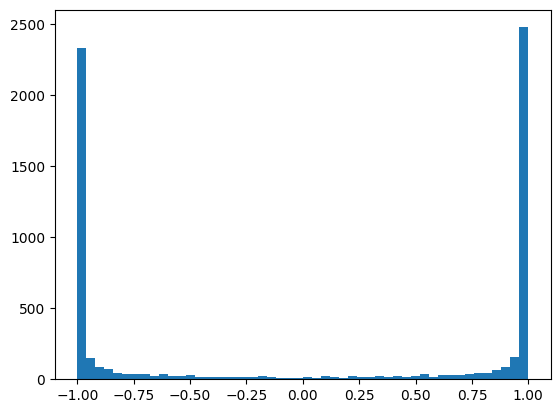

In [56]:
plt.hist(h.view(-1).tolist(), 50); #; removes the logs

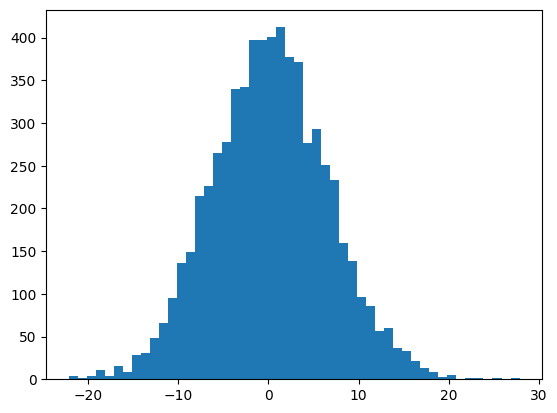

In [57]:
plt.hist(hpreact.view(-1).tolist(), 50); #; removes the logs

Since, my a lot of values in hpreact are outside the range -1+1....my tanh graph looks like this and hence soo many 1s in my h

Why are we so worried about the h graph??

Well...during backpropagation, we know, 
    h = torch.tanh(hpreact)
now, hpreact.grad = tanh.grad * h.grad, right?? (chain rule)
now...we know tanh.grad is (1 - t\*\*2)...therefore...
h.grad depends on t and out.grad/h.grad

now...h.grad is depended on 1-t\*\*2..so if t -> 1...tanh.grad->0...therefore...0*out.grad = 0...therfore...no gradients are flowing back to hpreact.. and what we will have is a dead neuron, ie...it might happen that by chance some logits are high, and then the neurons get knocked off, and then they dont have any gradients and then neuron dies

infact if you look at it...tanh only reduces the gradient..cause t is getting squared and the 1-t..so we are always reducing the gradient..and the larger the t, the more larger chunk we getting outta gradient....


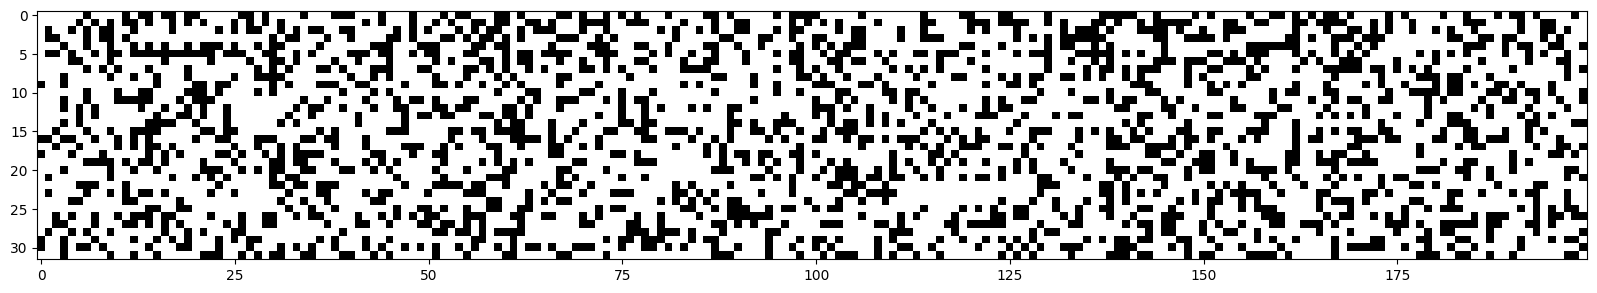

In [60]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest' )

Since we dont have a column of white we dont have a dead neuron

Why did this happen?? h depends on tanh and tanh depends on preact and preact depends on W1 and b1...so we can do the same we did to W2 and b2

In [70]:
n_embd = 10 #the dimensionality of char embedding vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * BLOCK_SIZE, n_hidden), generator=g) * 0.2 # making it small
b1 = torch.randn((n_hidden), generator=g) * 0.1 #making b1 small
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # same reason as b2
b2 = torch.randn((vocab_size), generator=g) * 0 # making this 0 since we blindly add it in the start

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [66]:
# same as before

lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())

    break


      0/ 200000 : 3.2987


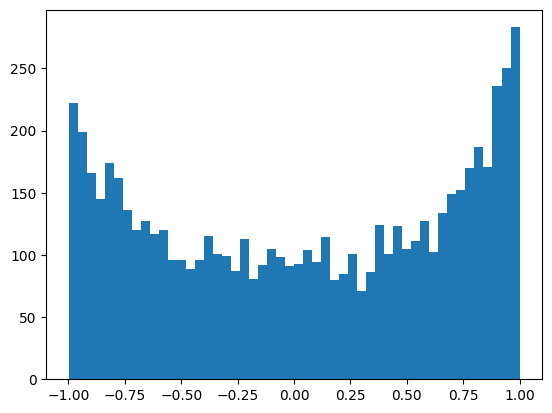

In [67]:
plt.hist(h.view(-1).tolist(), 50); #; removes the logs

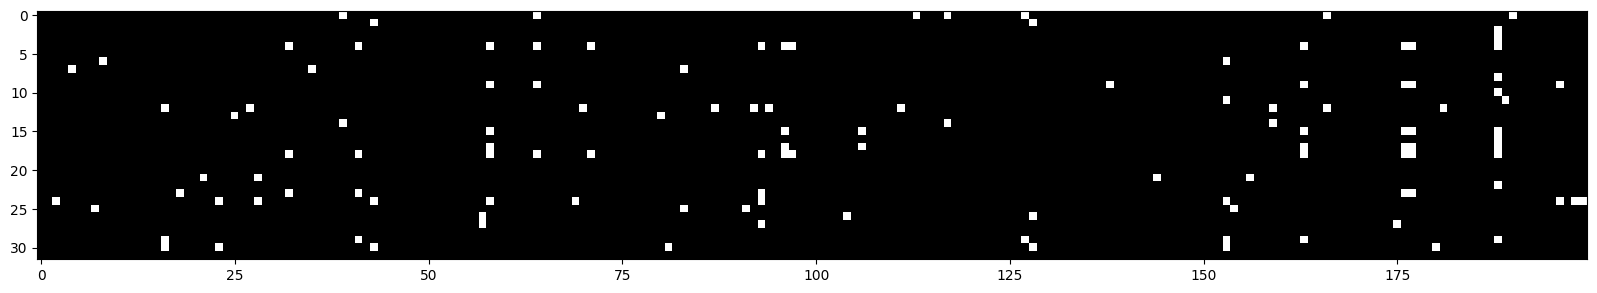

In [68]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest' )

Initial loss remained the same, but now all neurons are not saturated now...ie..no neuron is dead

Lets run it again now and check the loss

In [71]:
# same as before

lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())


      0/ 200000 : 3.2987
  10000/ 200000 : 1.8990
  20000/ 200000 : 2.2638
  30000/ 200000 : 2.0176
  40000/ 200000 : 2.4785
  50000/ 200000 : 1.8928
  60000/ 200000 : 1.6449
  70000/ 200000 : 2.1527
  80000/ 200000 : 2.5515
  90000/ 200000 : 2.1661
 100000/ 200000 : 2.1759
 110000/ 200000 : 1.8231
 120000/ 200000 : 2.2098
 130000/ 200000 : 1.9867
 140000/ 200000 : 2.0414
 150000/ 200000 : 2.1326
 160000/ 200000 : 1.9679
 170000/ 200000 : 2.0060
 180000/ 200000 : 2.3101
 190000/ 200000 : 2.2298


In [72]:
@torch.no_grad() # you can also use something called a context manager with this, look it up
def split_loss(split):
    x,y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test' : (Xte, yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0315563678741455
val 2.1410601139068604


Theres an improvement

So how to select by what factor to reduce the weights while initialization??

Also....We want the logits to be roughly guassian even after they are @ w1 + b1 thingy...so that we know nothing is saturated and no dead neurons

Well...theres a research paper on it by kaiming..and Kaiming says, that theres a formula...where he talks about a thing called gain which is different for each activation function

but factor is gain/sqrt(fan_in) now fan_in is nothing but number of inputs that weight is taking...

theres also a pytorch.nn.kaiming_init() function to initialize it...it has a lot of args like fan_in, fan_out, etc...but the same paper says, that choice doesnt matter much...

Also...if you dont want to ue kaiming or just wanna play around, you can always just divide the weights by sqrt of fan_in...works most of the time...but not super optimal ofcourse

#### Batch Normalization

Well, theres an easier way to deal with the initialization than kaiming as well...Batch Normalization paper by 2 guys in google

They just said..okay we need the hpreact to be gaussian before putting it in activation function right...well then why not just normalize it??

Why not just normalize the hidden state?

So basically, we do this

In [73]:
# same as before
lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    hpreact = (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True) #and this just works!
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())

    break


      0/ 200000 : 2.4271


But again, we dont wanna force the neural network to stay strictly gaussian...I mean as long as the weights arent too high and neurons dont die

So...we add 2 new parameters bngain, and bnbias (bn is batch_normalization)
So our initialization looks like

In [75]:
n_embd = 10 #the dimensionality of char embedding vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * BLOCK_SIZE, n_hidden), generator=g) * (5/3)/((n_embd * BLOCK_SIZE)**0.5) #kaiming's gain for tanh #* 0.2 # making it small
b1 = torch.randn((n_hidden), generator=g) * 0.1 #making b1 small
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # same reason as b2
b2 = torch.randn((vocab_size), generator=g) * 0 # making this 0 since we blindly add it in the start

bngain = torch.ones((1, n_hidden)) # initializing them as 1 rightnow but they will be optimized by the NN, so that network has enough room to optimize the distribution and not stick to strictly gaussian
bnbias = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [77]:
# same as before
lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())


      0/ 200000 : 3.3407
  10000/ 200000 : 1.9409
  20000/ 200000 : 2.1796
  30000/ 200000 : 2.1452
  40000/ 200000 : 2.4772
  50000/ 200000 : 1.8389
  60000/ 200000 : 1.7619
  70000/ 200000 : 2.2650
  80000/ 200000 : 2.4813
  90000/ 200000 : 2.2081
 100000/ 200000 : 2.0864
 110000/ 200000 : 1.8079
 120000/ 200000 : 2.3422
 130000/ 200000 : 1.9881
 140000/ 200000 : 2.1341
 150000/ 200000 : 2.2260
 160000/ 200000 : 2.0816
 170000/ 200000 : 2.1485
 180000/ 200000 : 2.3734
 190000/ 200000 : 2.2979


In [78]:
@torch.no_grad() # you can also use something called a context manager with this, look it up
def split_loss(split):
    x,y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test' : (Xte, yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True))/hpreact.std(0, keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.061927556991577
val 2.1418707370758057


Works well, now...if you see, logits depend upon h and h depends on hpreact, but....since batchNormalization hpreact is depending upon hpreact.mean() and hpreact.std(), and they both depend upon the other examples randomly tied together in the same batch...So....if you think about it...it's wrong...and that why people try to get rid of this thing and not use it...but...

Since, everytime a batch is randomly selected, h and logit will change a little bit due to randomness in examples...this actually helps prevent overfitting

Now for inference time....We expect the model to input a single example and then predict the output...but since our hpreact depends on batchMean and std...how do we get the inference??

Well, 2 things you can do..

1. Calculate the mean and std for the wholee training set before hand..and just use that mean during test time...
2. but since why would you calculate mean after the training...you can calculate it runningly..like this

In [80]:
n_embd = 10 #the dimensionality of char embedding vectors
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * BLOCK_SIZE, n_hidden), generator=g) * (5/3)/((n_embd * BLOCK_SIZE)**0.5) #kaiming's gain for tanh #* 0.2 # making it small
b1 = torch.randn((n_hidden), generator=g) * 0.1 #making b1 small
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # same reason as b2
b2 = torch.randn((vocab_size), generator=g) * 0 # making this 0 since we blindly add it in the start

bngain = torch.ones((1, n_hidden)) # initializing them as 1 rightnow but they will be optimized by the NN, so that network has enough room to optimize the distribution and not stick to strictly gaussian
bnbias = torch.ones((1, n_hidden))
bnmean_running = torch.ones((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12297


In [81]:
# same as before
lr_start = 0.1
lr_decay_rate = 0.01
EPOCHS = 200000
BATCH_SIZE = 32
lossi =  []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    #forward pass

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1) 
    hpreact = embcat @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani)/bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running =  0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, yb)


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_start if epoch < EPOCHS*0.5 else lr_decay_rate
    for p in parameters:
        p.data -= lr*p.grad

    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d} : {loss.item():.4f}")
    lossi.append(loss.log10().item())


      0/ 200000 : 3.3407
  10000/ 200000 : 1.9409
  20000/ 200000 : 2.1796
  30000/ 200000 : 2.1452
  40000/ 200000 : 2.4772
  50000/ 200000 : 1.8389
  60000/ 200000 : 1.7619
  70000/ 200000 : 2.2650
  80000/ 200000 : 2.4813
  90000/ 200000 : 2.2081
 100000/ 200000 : 2.0864
 110000/ 200000 : 1.8079
 120000/ 200000 : 2.3422
 130000/ 200000 : 1.9881
 140000/ 200000 : 2.1341
 150000/ 200000 : 2.2260
 160000/ 200000 : 2.0816
 170000/ 200000 : 2.1485
 180000/ 200000 : 2.3734
 190000/ 200000 : 2.2979


In [82]:
@torch.no_grad() # you can also use something called a context manager with this, look it up
def split_loss(split):
    x,y = {
        'train': (Xtr, ytr),
        'val': (Xde, yde),
        'test' : (Xte, yte)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running)/ bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0618836879730225
val 2.1422741413116455


Also a note, if you look closely, we are adding b1 as a bias to all examples in hpreact but then we are calculating its mean and then subtracting it...So adding a bias is useless...So its better to not add bias before the batch normalization layer, and to be fair we still have the bnbias to take care of stuff

Part 2: Let's pytorch-ify our code, aka make the layers

In [12]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias=True) -> None:
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # paramteres to be trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.randn(dim)

        # buffers for running mean and std
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x: torch.Tensor) -> Any:
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_std
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum)* self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x: torch.Tensor) -> Any:
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [22]:
n_embd = 10 # dimensionality of the embedding vector
n_hidden = 100 # no of neurons
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * BLOCK_SIZE, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # last layer() make loss confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


46497


In [23]:
# same as last time with some changes

EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    
    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

    break

      0/ 200000: 3.2954


As you can see...due to the initial gain we multiplied by (5/3), all the other layers are not saturated...but the first layer is still bit saturated

layer 1 (      Tanh): mean -0.05, std 0.76, saturated: 21.69%
layer 3 (      Tanh): mean -0.01, std 0.68, saturated: 8.28%
layer 5 (      Tanh): mean +0.00, std 0.67, saturated: 6.66%
layer 7 (      Tanh): mean -0.01, std 0.66, saturated: 5.12%
layer 9 (      Tanh): mean -0.02, std 0.66, saturated: 6.28%


Text(0.5, 1.0, 'activation distribution')

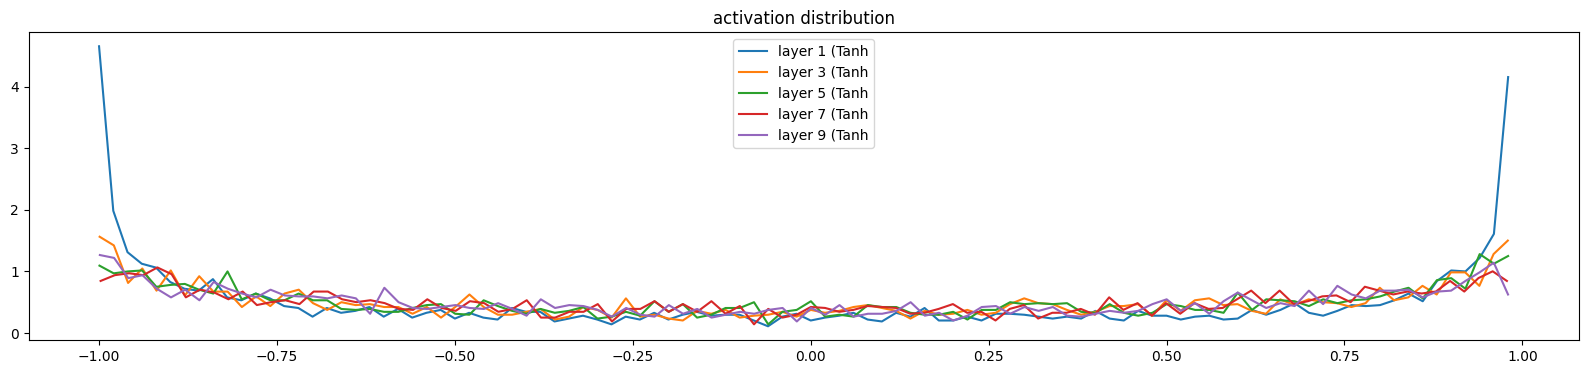

In [24]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

Gradients look good tho

layer 1 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

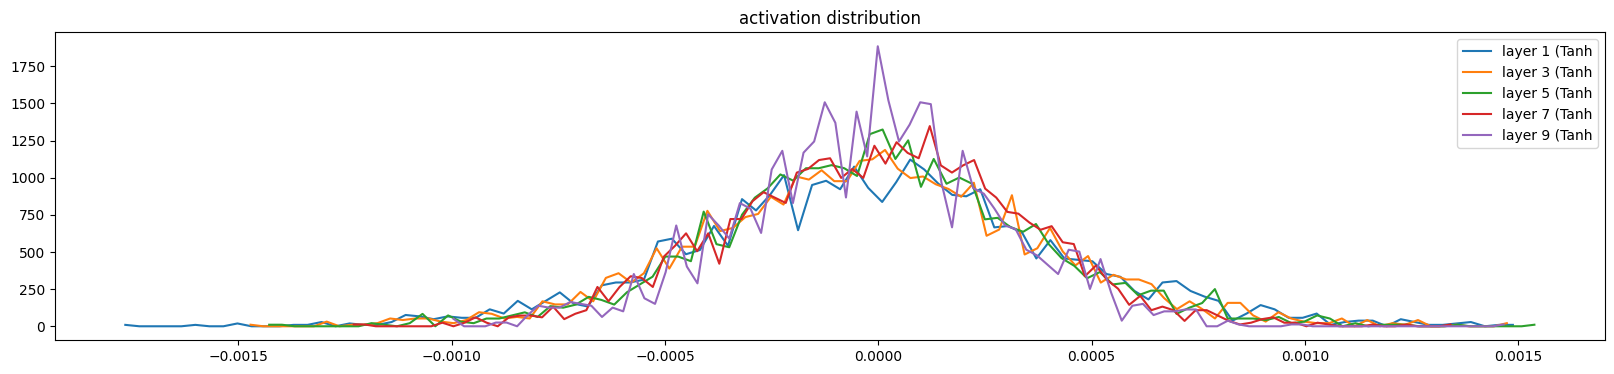

In [25]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

Activations seem good and they follow normal distribution, its okay,

but if i change 5/3 to 1 or something, so no kaiming initialization

In [19]:
n_embd = 10 # dimensionality of the embedding vector
n_hidden = 100 # no of neurons
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * BLOCK_SIZE, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # last layer() make loss confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


46497


In [20]:
# same as last time with some changes

EPOCHS = 200000
BATCH_SIZE = 32
lossi = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    
    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

    break

      0/ 200000: 3.2947


layer 1 (      Tanh): mean -0.04, std 0.63, saturated: 3.75%
layer 3 (      Tanh): mean -0.01, std 0.47, saturated: 0.00%
layer 5 (      Tanh): mean +0.01, std 0.40, saturated: 0.06%
layer 7 (      Tanh): mean -0.00, std 0.35, saturated: 0.00%
layer 9 (      Tanh): mean -0.01, std 0.32, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

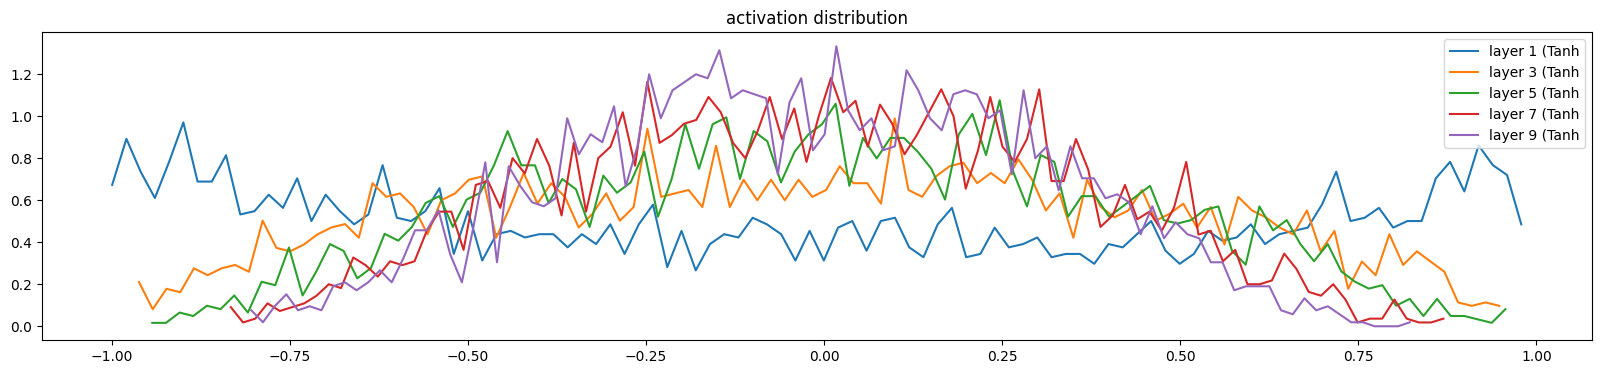

In [21]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

Now, a lot of layers are saturated, thats why we need kaiming init

##### Why Activation Functions?

- Without activations, stacking linear layers collapses into one linear model.
- Linear models can only learn linearly separable functions (can’t solve XOR).
- Activation functions add **non-linearity**, making neural networks **universal function approximators**.

##### Why not quadratic/cubic activations?

- Polynomial activations cause **exploding or vanishing gradients** when stacked.
- Polynomial degree grows exponentially with depth → numerical instability.
- Quadratic functions lose sign information (`f(x) = f(-x)`).

##### Why ReLU / GELU?

- Stable gradients (no explosion).
- No saturation on positive side.
- Easy to optimize in deep networks.
- Just enough non-linearity without breaking training.

Lets check the gradients and the data of weights now

weight   (27, 10) | mean -0.000043 | std 1.376150e-03 | grad:data ratio 1.375150e-03
weight  (30, 100) | mean +0.000015 | std 1.295205e-03 | grad:data ratio 4.153098e-03
weight (100, 100) | mean +0.000007 | std 1.067305e-03 | grad:data ratio 6.424886e-03
weight (100, 100) | mean -0.000006 | std 9.006738e-04 | grad:data ratio 5.364867e-03
weight (100, 100) | mean +0.000001 | std 8.206051e-04 | grad:data ratio 4.908468e-03
weight (100, 100) | mean -0.000003 | std 6.871594e-04 | grad:data ratio 4.106277e-03
weight  (100, 27) | mean +0.000000 | std 2.244485e-02 | grad:data ratio 2.215080e+00


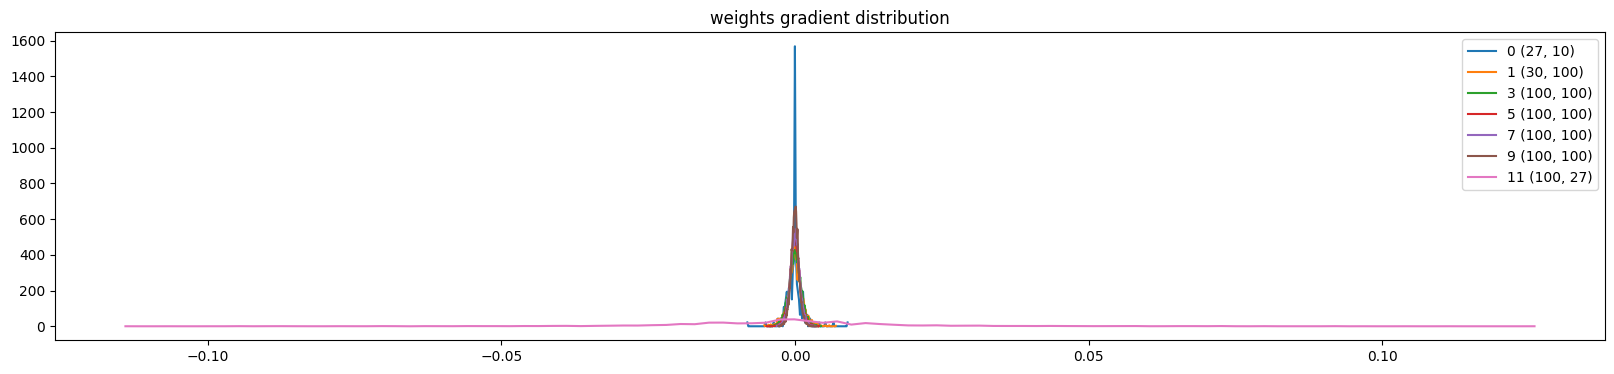

In [26]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



take a close look to last layers, grad/data ratio...its much bigger than other layers...
SO look at last row of logs, the grad:data ratio is big, ie...the gradient is double than the data, this means in backward pass...this huge gradient will be multiplied to other gradients and be super big...causing instability while training

Now, if you run the training a little longer, this issue kinda slows down, but still it means the weight initialization hasnt been done properly

Also this might be an issue if youre using SGD (since gradients will become huge) and not something like adam (will study about it later)


Now 1 more thing, what is more important is actually not grad:data but update:data...So lets track that

In [30]:
n_embd = 10 # dimensionality of the embedding vector
n_hidden = 100 # no of neurons
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * BLOCK_SIZE, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # last layer() make loss confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


46497


In [31]:
# same as last time with some changes

EPOCHS = 200000
BATCH_SIZE = 32
lossi = []
ud = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    
    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # adding the standard dev of update:data ratio

    if epoch >= 1000:
        break

      0/ 200000: 3.2954


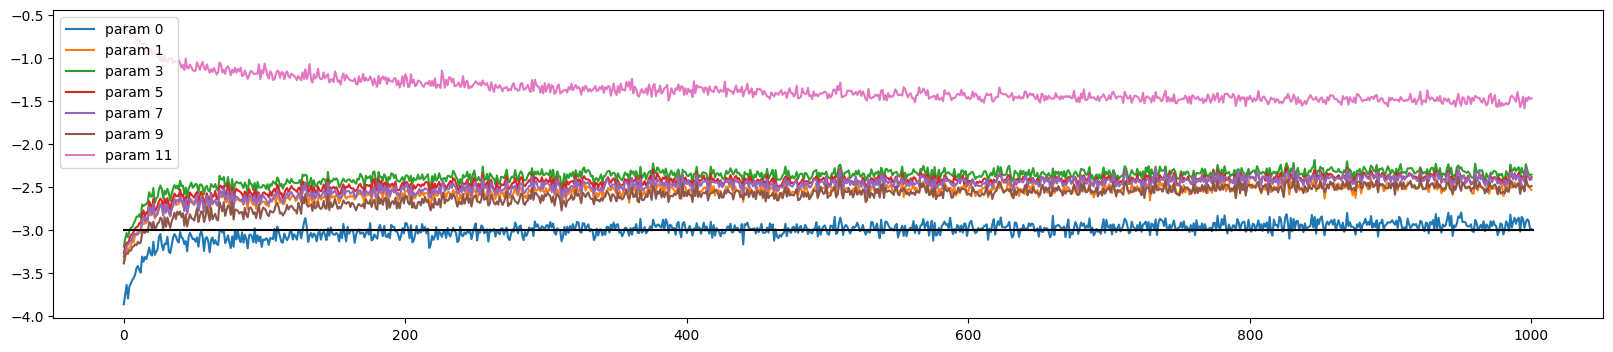

In [32]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d'%i)
plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

As you can see, the 1st layer is good, since its near the black line...but other layers kinda keep getting larger and larger...now why do we have that the final layer is gettin updated so much??

Its because we artifically had reduced the bias by 0.1 

Now what happens if our weights arent caliberated?? they arent stable

In [33]:
from typing import Any


class Linear:
    def __init__(self, fan_in, fan_out, bias=True) -> None:
        self.weight = torch.randn((fan_in, fan_out), generator=g) # imagine we forget to put this initialization thingy / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x) -> Any:
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # paramteres to be trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.randn(dim)

        # buffers for running mean and std
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x: torch.Tensor) -> Any:
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_std
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum)* self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x: torch.Tensor) -> Any:
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [34]:
n_embd = 10 # dimensionality of the embedding vector
n_hidden = 100 # no of neurons
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * BLOCK_SIZE, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Tanh(),
    Linear(n_hidden, vocab_size)
]

with torch.no_grad():
    # last layer() make loss confident
    layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


46497


In [35]:
# same as last time with some changes

EPOCHS = 200000
BATCH_SIZE = 32
lossi = []
ud = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    
    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # adding the standard dev of update:data ratio

    if epoch >= 1000:
        break

      0/ 200000: 3.4036


layer 1 (      Tanh): mean -0.02, std 0.99, saturated: 96.38%
layer 3 (      Tanh): mean -0.01, std 0.98, saturated: 90.97%
layer 5 (      Tanh): mean +0.00, std 0.98, saturated: 91.00%
layer 7 (      Tanh): mean -0.05, std 0.98, saturated: 90.03%
layer 9 (      Tanh): mean -0.05, std 0.98, saturated: 90.28%


Text(0.5, 1.0, 'activation distribution')

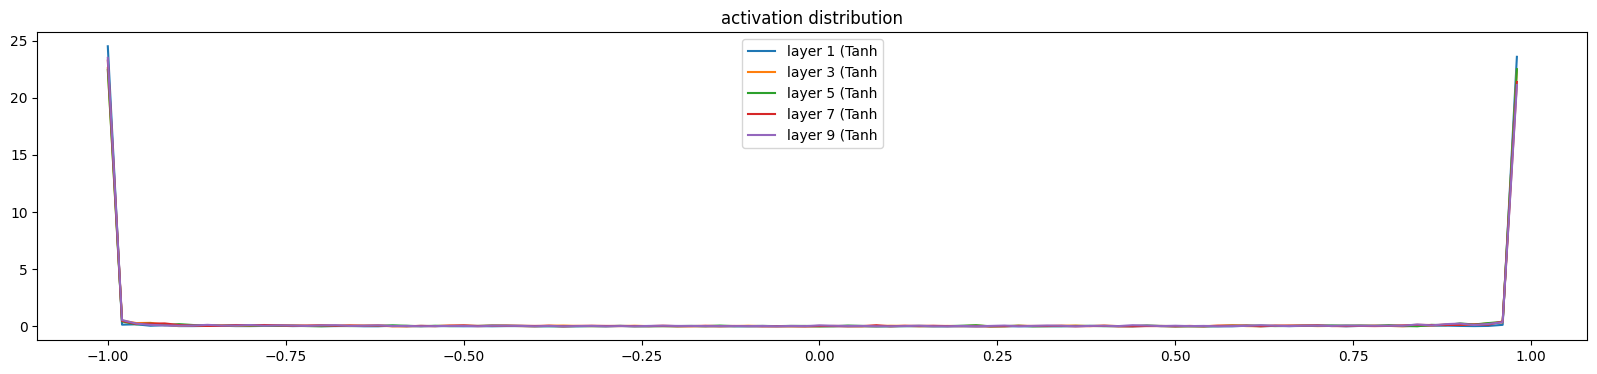

In [36]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

Gradients are saturated

weight   (27, 10) | mean +0.001157 | std 3.289974e-01 | grad:data ratio 1.316489e-01
weight  (30, 100) | mean -0.001866 | std 1.673055e-01 | grad:data ratio 8.676373e-02
weight (100, 100) | mean +0.000571 | std 3.352722e-02 | grad:data ratio 2.007163e-02
weight (100, 100) | mean +0.000084 | std 1.118764e-02 | grad:data ratio 6.659769e-03
weight (100, 100) | mean +0.000036 | std 4.011638e-03 | grad:data ratio 2.399434e-03
weight (100, 100) | mean +0.000016 | std 1.505766e-03 | grad:data ratio 8.998302e-04
weight  (100, 27) | mean -0.000000 | std 3.015953e-02 | grad:data ratio 4.874700e-01


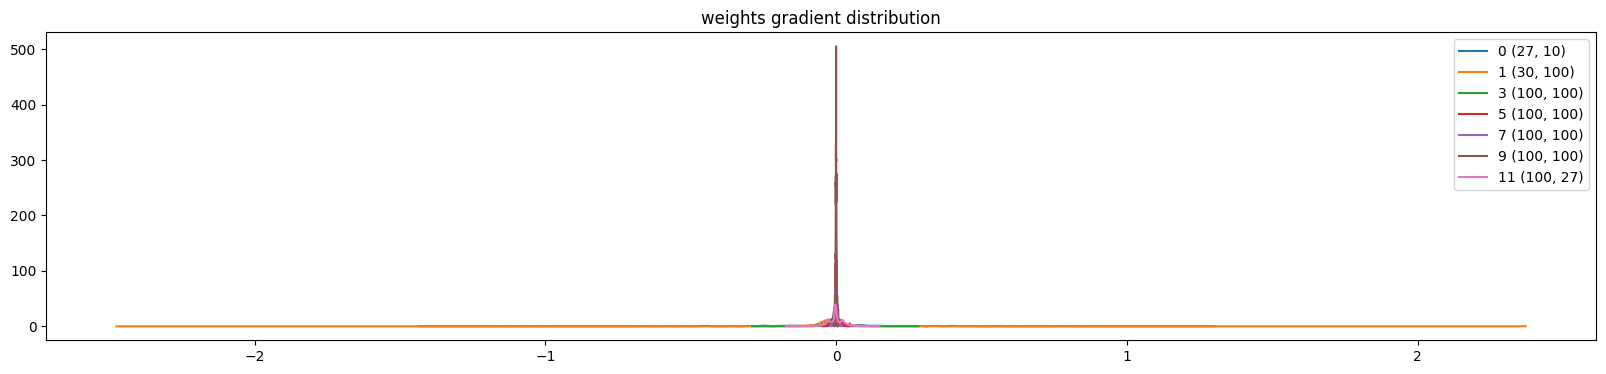

In [37]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



grad:data ratio is not good, ratios are too large

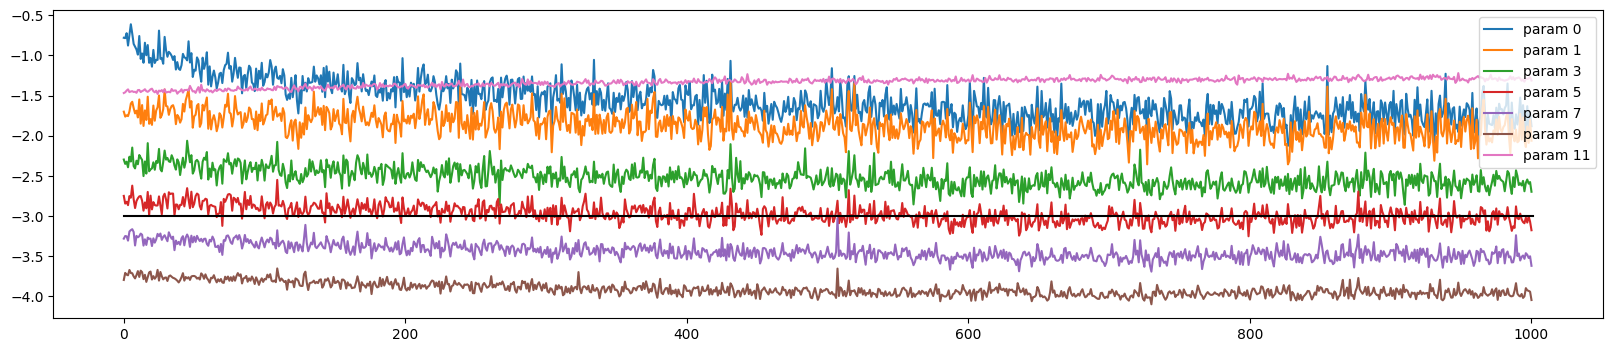

In [38]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d'%i)
plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

Model training is too unstable

Lets add BN

In [57]:
n_embd = 10 # dimensionality of the embedding vector
n_hidden = 100 # no of neurons
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * BLOCK_SIZE, n_hidden),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    BatchNorm1d(n_hidden),
    Tanh(),
    Linear(n_hidden, n_hidden),
    Linear(n_hidden, vocab_size),
    BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer() make loss confident
    layers[-1].gamma *= 0.1 #updateing gamma and not weight
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


47351


In [58]:
# same as last time with some changes

EPOCHS = 200000
BATCH_SIZE = 32
lossi = []
ud = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad

    
    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # adding the standard dev of update:data ratio

    if epoch >= 1000:
        break

      0/ 200000: 3.5068


layer 2 (      Tanh): mean +0.06, std 0.72, saturated: 14.50%
layer 5 (      Tanh): mean +0.02, std 0.71, saturated: 11.97%
layer 8 (      Tanh): mean +0.11, std 0.73, saturated: 16.59%
layer 11 (      Tanh): mean -0.06, std 0.72, saturated: 13.50%


Text(0.5, 1.0, 'activation distribution')

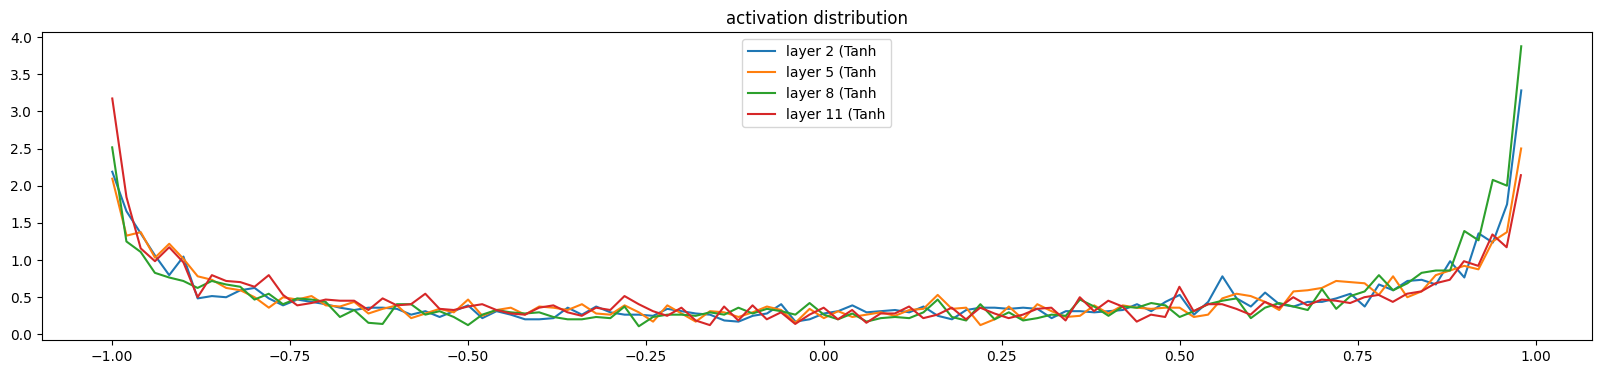

In [59]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

weight   (27, 10) | mean +0.000000 | std 5.730509e-03 | grad:data ratio 5.725572e-03
weight  (30, 100) | mean -0.000019 | std 1.089200e-03 | grad:data ratio 6.376498e-04
weight (100, 100) | mean +0.000005 | std 5.438619e-04 | grad:data ratio 3.273901e-04
weight (100, 100) | mean +0.000006 | std 4.887264e-04 | grad:data ratio 2.911094e-04
weight (100, 100) | mean -0.000004 | std 4.567456e-04 | grad:data ratio 2.732035e-04
weight (100, 100) | mean -0.000002 | std 3.447622e-04 | grad:data ratio 2.060205e-04
weight  (100, 27) | mean +0.000002 | std 7.334792e-04 | grad:data ratio 4.451151e-04


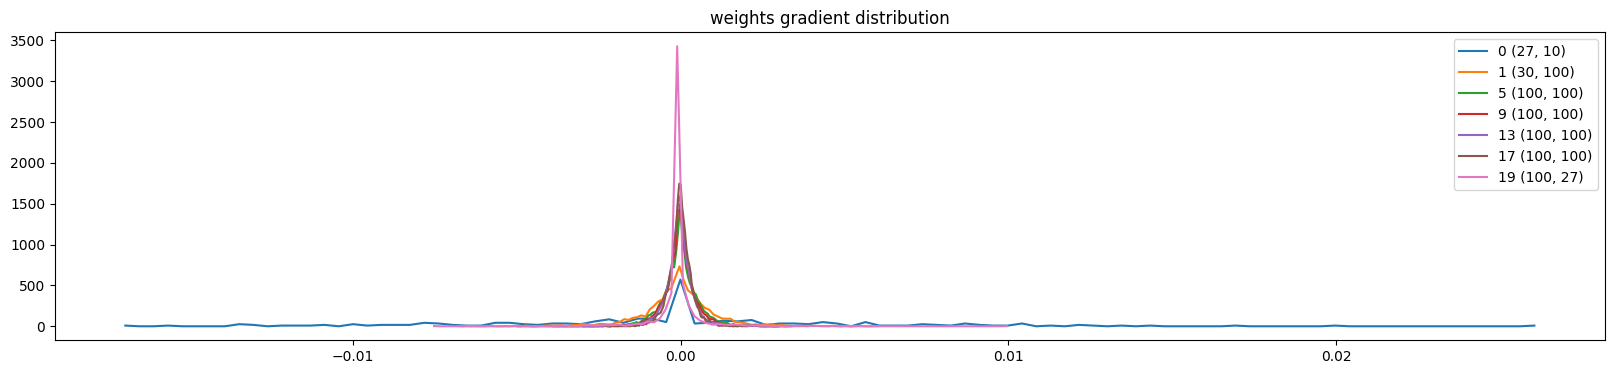

In [60]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



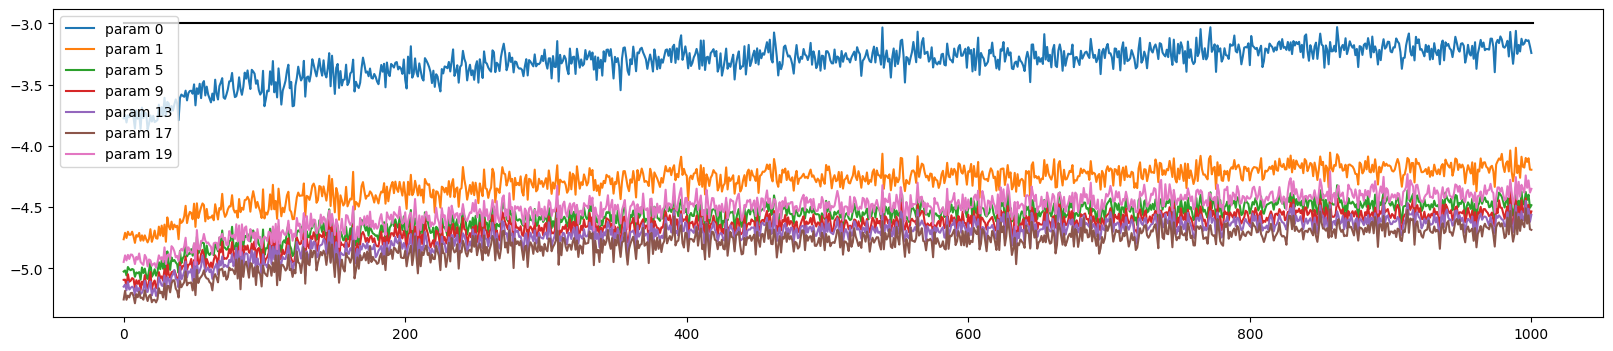

In [61]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d'%i)
plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

Saturation is still there a little bit, so it does mean we still need to adjust the gain a little bit... So the gain at 5/3 was good

After changing it back 5/3 its good...i mean still 12% saturated gradients but its okay, not that bad...with tanh and a deep network its inevitable of some saturation

But looking at the last viz, i can tell the LR is too small...learning is too slow for 2nd layer and so on

and why is that, cause our Linear class doesnt have the kaiming initialization, fan_in**0.5 thingy...hence, our initial weights are a bit large in magnitude and thus, LR needs to be bumped up a bit

In [62]:
# same as last time with some changes

EPOCHS = 200000
BATCH_SIZE = 32
lossi = []
ud = []

for epoch in range(EPOCHS):
    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ), generator=g)
    Xb, yb = Xtr[ix], ytr[ix]

    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 1 if epoch < 100000 else 0.01 # bumping up the LR
    for p in parameters:
        p.data -= lr * p.grad

    
    # track stats
    if epoch % 10000 == 0:
        print(f"{epoch:7d}/{EPOCHS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters]) # adding the standard dev of update:data ratio

    if epoch >= 1000:
        break

      0/ 200000: 2.6977


layer 2 (      Tanh): mean +0.05, std 0.74, saturated: 15.47%
layer 5 (      Tanh): mean -0.01, std 0.72, saturated: 11.97%
layer 8 (      Tanh): mean +0.13, std 0.76, saturated: 16.25%
layer 11 (      Tanh): mean -0.06, std 0.73, saturated: 12.19%


Text(0.5, 1.0, 'activation distribution')

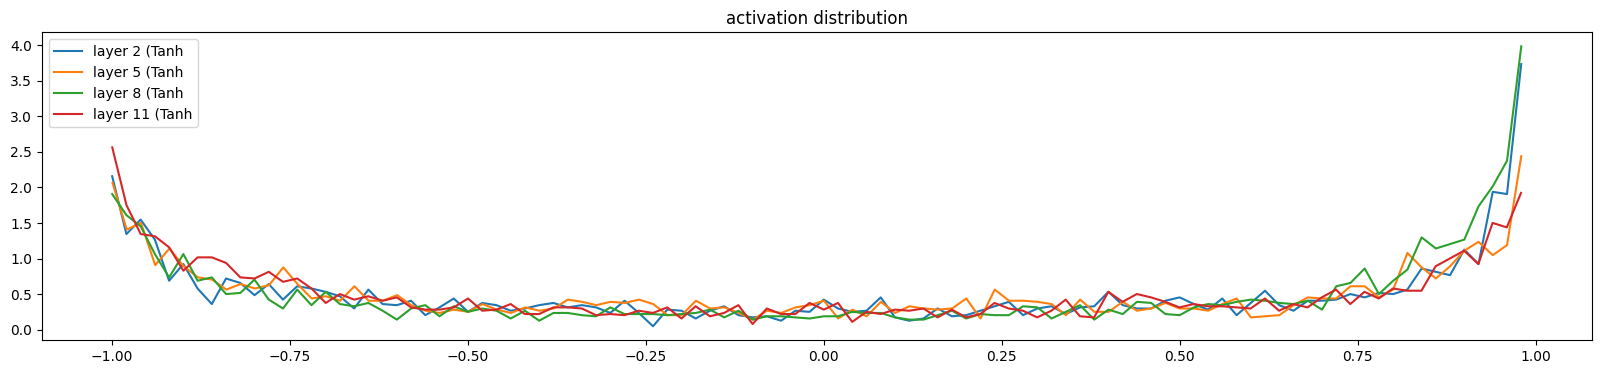

In [63]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

weight   (27, 10) | mean -0.000000 | std 8.996814e-03 | grad:data ratio 8.651517e-03
weight  (30, 100) | mean +0.000028 | std 1.958638e-03 | grad:data ratio 1.146080e-03
weight (100, 100) | mean -0.000002 | std 9.258342e-04 | grad:data ratio 5.572549e-04
weight (100, 100) | mean +0.000007 | std 7.845288e-04 | grad:data ratio 4.672601e-04
weight (100, 100) | mean +0.000010 | std 7.611918e-04 | grad:data ratio 4.552738e-04
weight (100, 100) | mean -0.000011 | std 6.920879e-04 | grad:data ratio 4.135467e-04
weight  (100, 27) | mean -0.000039 | std 1.365270e-03 | grad:data ratio 8.283121e-04


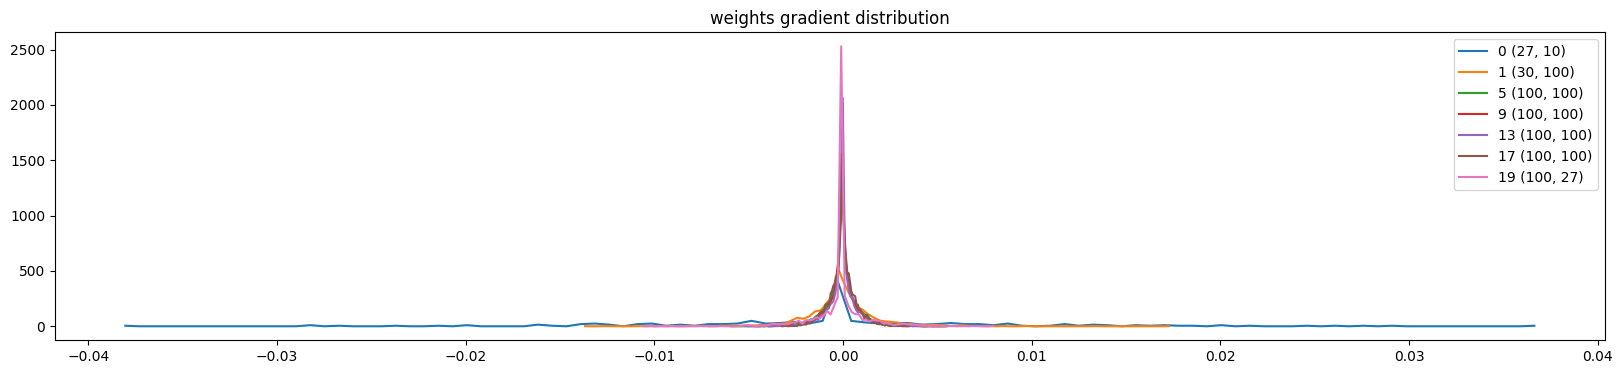

In [64]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');



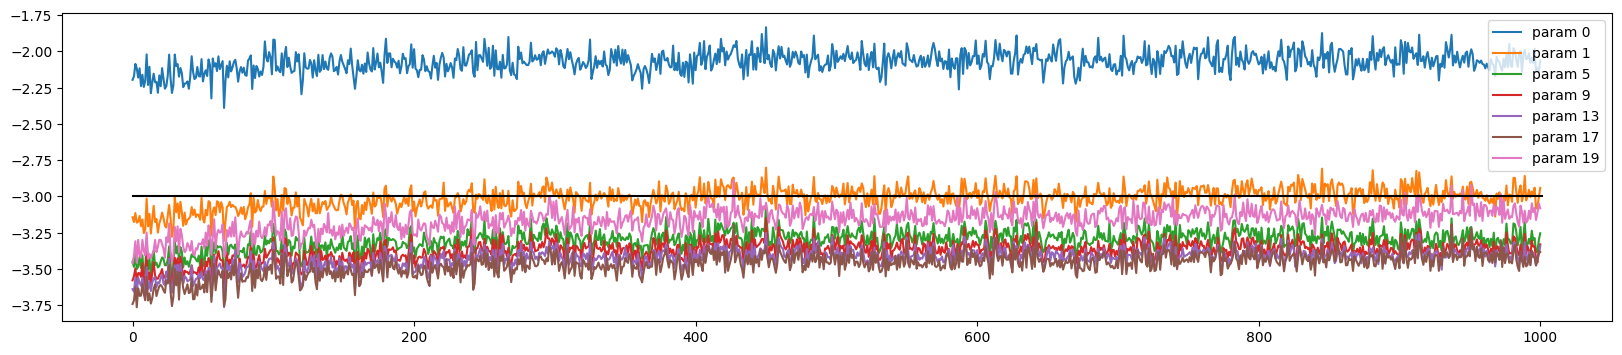

In [65]:
plt.figure(figsize=(20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d'%i)
plt.plot([0, len(ud)], [-3,-3], 'k')
plt.legend(legends)

Everything now looks normal and our learning is also good